In [1]:
# imports and configuration
import os, torch, pandas as pd
from mt4xai.model import load_lstm_model
from mt4xai.data import split_data, apply_scalers, fit_scalers_on_train, build_loader
from mt4xai.test import run_mt4xai_user_test

# project paths (adjust if needed)
PROJECT_ROOT = os.getcwd()
DATA_FP  = os.path.join(PROJECT_ROOT, "../Data",   "etron55-charging-sessions.parquet")
MODEL_FP = os.path.join(PROJECT_ROOT, "../Models", "final", "final_model.pth")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
# load model
model, ckpt = load_lstm_model(MODEL_FP, device=device)
input_features  = ckpt["input_features"]
target_features = ckpt["target_features"]
H = int(ckpt["config"]["horizon"])  # forecast horizon
POWER_WEIGHT = float(ckpt["config"].get("power_weight", 0.5))
idx_power_inp = input_features.index("power")
idx_soc_inp   = input_features.index("soc")

/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/src/mt4xai/model.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch

In [3]:
# load and scale data (same preprocessing as modelling/AD)
df = pd.read_parquet(DATA_FP)
drop_cols = [c for c in [
    "energy","charger_category","timestamp","nearest_weather_station",
    "timestamp_d","lat","lon","timestamp_H"
] if c in df.columns]
df = df.drop(columns=drop_cols).copy()

train_df, val_df, test_df = split_data(df, test_size=0.2, validation_size=0.1)
scalers = fit_scalers_on_train(train_df, list(set(input_features) | set(target_features)))
power_scaler, soc_scaler = scalers["power"], scalers["soc"]
test_s = apply_scalers(test_df, scalers)

test_loader = build_loader(test_s, input_features, target_features, H,
                           batch_size=16, shuffle=False, num_workers=0)

In [4]:
len(test_loader.dataset.groups)

12183

[session 5649864] base=ABNORMAL (34.00) | simplified=ABNORMAL (33.47), k=12, robust=1.000


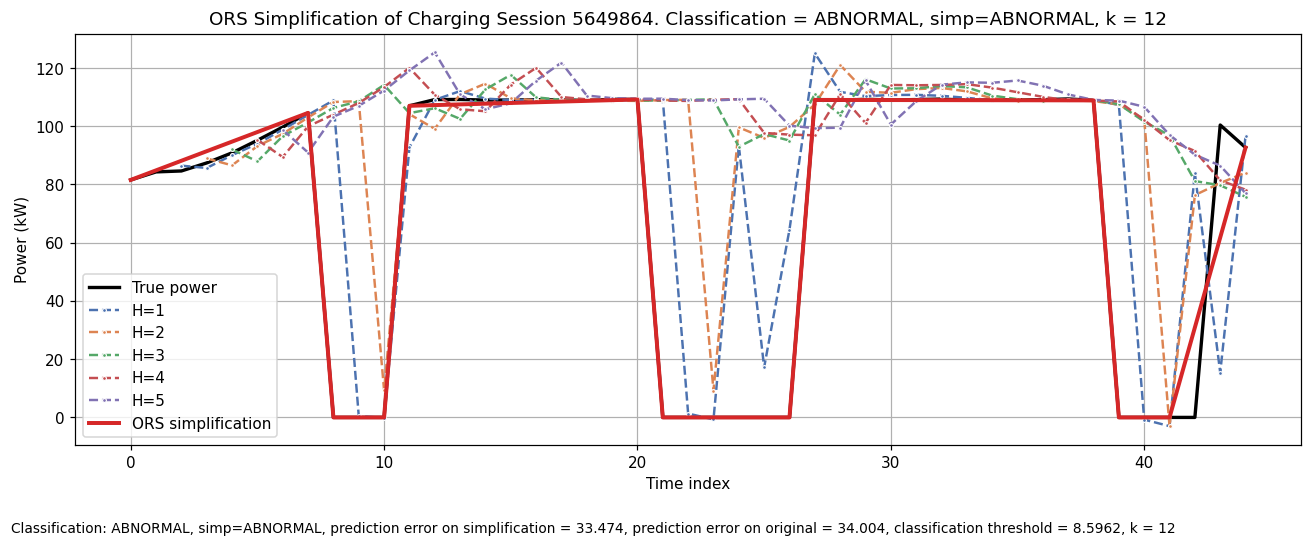

In [5]:
# pick a session and run the unified pipeline
SESSION_ID = 5649864
BATCH_INDEX, SAMPLE_INDEX = 10, 0  # used only if SESSION_ID is None

THRESHOLD = 8.5962  # absolute Macro-RMSE threshold: 95th percentile RMSE for the val set

res = run_mt4xai_user_test(
    model, test_loader,
    power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
    power_weight=POWER_WEIGHT, decay_lambda=0.2,
    threshold=THRESHOLD,
    t_min_eval=1,
    session_id=SESSION_ID,
    # batch_index=BATCH_INDEX, sample_index=SAMPLE_INDEX,
)

print(f"[session {res.session_id}] base={res.base_label} ({res.base_error:.2f}) | "
      f"simplified={res.simplified_label} ({res.simplified_error:.2f}), "
      f"k={res.k}, robust={res.robust_prob:.3f}")